# Predicting California Housing Prices with Custom Linear Regression and Gradient Descent

## Table of Contents
- [Table of Contents](#table-of-contents)
- [Introduction](#introduction)
  - [Project Description](#project-description)
  - [Aims](#aims)
- [Data Preparation and Preprocessing](#data-preparation-and-preprocessing)
  - [Libraries](#libraries)
  - [Data Provenance](#data-provenance)
  - [Feature Selection](#feature-selection)
  - [Removing Data Outliers](#removing-data-outliers)
  - [Dataset Splitting in Test and Training](#dataset-splitting-in-test-and-training)
- [Linear Regression Concepts](#linear-regression-concepts)
  - [Simple Linear Regression](#simple-linear-regression)
  - [Simple Linear Regression Methodology](#simple-linear-regression-methodology)
  - [Gradient Descent Regression](#gradient-descent-regression)
  - [Gradient Descent Regression Methodology](#gradient-descent-regression-methodology)
- [Linear Regression Models](#linear-regression-models)
  - [MyLinearRegression Algorithm Design](#mylinearregression-algorithm-design)
  - [MyGradientDescent Algorithm Design](#mygradientdescent-algorithm-design)
- [Evaluation](#evaluation)
  - [Predictions Using California Housing Data](#predictions-using-california-housing-data)
    - [MyLinearRegression Predictions](#mylinearregression-predictions)
    - [SkLearn Linear Regression Predictions](#sklearn-linear-regression-predictions)
    - [MyGradientDescent Predictions](#mygradientdescent-predictions)
  - [Visualizations](#visualizations)
    - [Gradient Descent Loss Curve](#gradient-descent-loss-curve)
    - [Actual vs Predicted Plots](#actual-vs-predicted-plots)
    - [Regression Lines Plots](#regression-lines-plots)
    - [Residuals Comparison Plot](#residuals-comparison-plot)
  - [Metrics Comparison](#metrics-comparison)
- [Conclusion](#conclusion)
- [References](#references)


## Introduction
This project explains the methodologies and algorithms of simple linear regression and gradient descent regression. 
### Project Description
Regression algorithms help make predictions of continuous data values. These algorithms form part of supervised learning. In machine learning, supervised learning is dependent on the labels given in the training process. 
When choosing the best algorithm for the data, we are faced with many algorithms that make it difficult to understand which is the best option. For that reason, this report focuses on explaining the differences between two linear regression algorithms.  
The purpose of this report is to find the differences between simple linear regression and gradient descent algorithms. In the following cells the two algorithms are built from scratch to understand the steps and functions that the algorithm performs. Further information will be found in the report to explain the differences.


### Aims
The aim of this report is to explain the difference between two types of linear regression algorithms methods: simple linear regression and gradient descent.
- Investigate methods, attributes and parameters of simple linear regression and gradient descent.
- Understand the equations behind linear regression and gradient descent
- Build a simple linear regression algorithm and compare it with the SkLearn LinearRegression model.
- Build gradient descent algorithm.
- Make a comparison between algorithms by visualizing and explaining the results.

## Data Preparation and Preprocessing
This section explains the data provenance and the data preprocessing. It focuses in finding the optimal feature for the model, cleaning the data and splitting the datasets.

### Libraries

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

### Data Provenance
The California Housing Values (SkLearn.datasets) dataset was extracted from the SkLearn datasets provided in the following page:
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing
The dataset's original provenance is from the following website  http://lib.stat.cmu.edu/datasets/ (StatLib).

In [37]:
# Import data from sklearn datasets
data_housing = datasets.fetch_california_housing()

In [38]:
housing_df = pd.DataFrame(data_housing.data, columns=data_housing.feature_names)
housing_df[data_housing.target_names[0] + '(Target)'] = data_housing.target
housing_df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal(Target)
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [39]:
print("Number of samples in the dataset:", housing_df.shape[0])
print("Number of features in the dataset:", housing_df.shape[1] - 1)  # Subtracting 1 for the target column

Number of samples in the dataset: 20640
Number of features in the dataset: 8


### Feature Selection 
Feature selection is a process where only the features that have better statistical significance to the target are kept.
The California Housing dataset contains seven features. For the simple linear regression model, only one feature is used. The SelectKBest algorithm from SkLearn library (SkLearn.Feature_selection) is a method for filtering the best features using the K highest statistical score. The SelectKBest is used to choose the best three features from the dataset.

In [40]:
# Initiate the selection model
feat = SelectKBest(score_func=f_regression, k=3)

# Passes the data and the target as parameters to selects 3 features with the higest scores
housing_feat = feat.fit_transform(data_housing.data, data_housing.target)

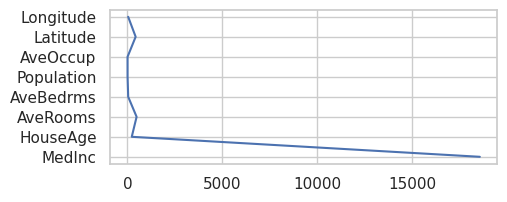

In [60]:
# Plot the scores returned by the slection model
plt.figure(figsize=(5,2))
plt.plot(feat.scores_, data_housing.feature_names)

# save plot to file as png
plt.savefig('./Assets/feature-selection.png', bbox_inches='tight', dpi=300)
plt.show()

In [42]:
# Show features' scores  for the data and the target
print("Indices of the features: ", feat.get_support(True))

print(data_housing.feature_names[0], feat.scores_[0])
print(data_housing.feature_names[2], feat.scores_[2])
print(data_housing.feature_names[6], feat.scores_[6])

Indices of the features:  [0 2 6]
MedInc 18556.571631293384
AveRooms 487.75746169668895
Latitude 438.0054534276914


Using the previous feature selection, the **MedInc** feature was chosen to train **myLinearRegression** model because this feature contains linear dependency between a feature and the target variable.

### Removing Data Outliers  
To remove data outliers, extreme values are identified and trimmed. The following box plots show the outliers for the feature and the target data  

In [43]:
# Creates an array of features and target 
X_data = housing_feat[:, 0]
y_data = data_housing.target 

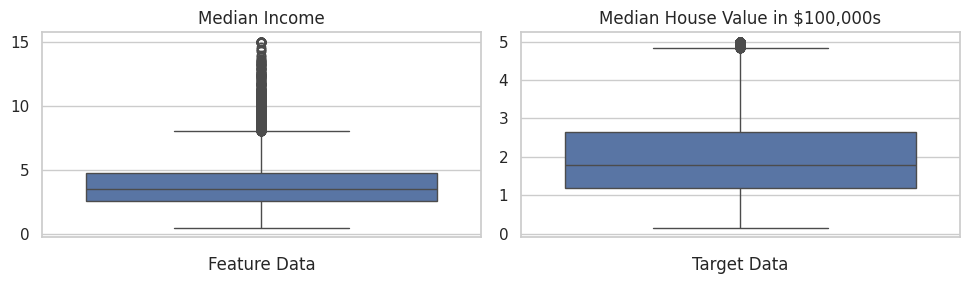

In [61]:
# Plots the data and the target in two different plots
plt.figure(figsize=(10, 3)) 

# first plot
plt.subplot(1, 2, 1) 
sns.boxplot(X_data) 
plt.xlabel("Feature Data")
plt.title("Median Income")

# second plot 
plt.subplot(1, 2, 2) 
sns.boxplot(y_data) 
plt.xlabel("Target Data")
plt.title("Median House Value in $100,000s")

plt.tight_layout()

# save plot to file as png
plt.savefig('./Assets/eda.png', bbox_inches='tight', dpi=300)
plt.show()

In [45]:
# Remove outliers from the feature and target data using the values from the boxplots
Xy = pd.DataFrame({'X' : X_data, 'y' : y_data})
Xy.drop(Xy[Xy['X'] > 8].index, inplace=True)
Xy.drop(Xy[Xy['y'] > 5].index, inplace=True)
Xy.drop(Xy[(Xy['X'] > 7) & (Xy['y'] < 2.5) ].index, inplace=True)
Xy.drop(Xy[(Xy['X'] > 6) & (Xy['y'] < 1.5) ].index, inplace=True)
Xy.drop(Xy[(Xy['X'] > 5) & (Xy['y'] < 1) ].index, inplace=True)
Xy.drop(Xy[(Xy['X'] < 4) & (Xy['y'] > 4) ].index, inplace=True)
Xy.drop(Xy[(Xy['X'] < 2) & (Xy['y'] > 2.5) ].index, inplace=True)
Xy.drop(Xy[(Xy['X'] < 1) & (Xy['y'] > 2) ].index, inplace=True)

X_housing = np.array(Xy['X'])
y_housing = np.array(Xy['y'])

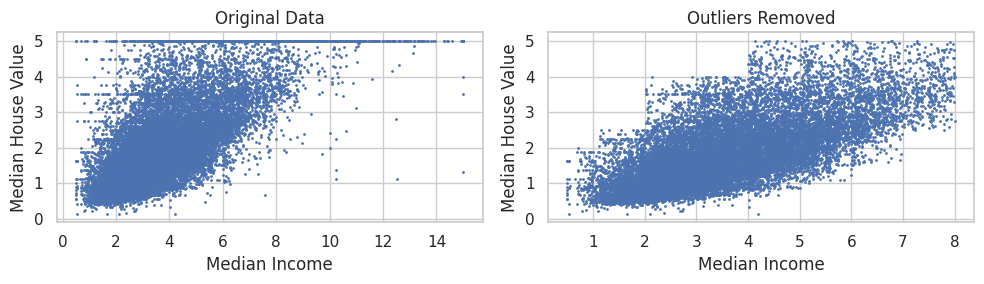

In [62]:
plt.figure(figsize=(10, 3)) 

# first plot
plt.subplot(1, 2, 1) 
plt.scatter(X_data, y_data, s=1)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Original Data")

# second plot 
plt.subplot(1, 2, 2) 
plt.scatter(X_housing, y_housing, s=1)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Outliers Removed")

plt.tight_layout()

# save plot to file as png
plt.savefig('./Assets/preprocessing.png', bbox_inches='tight', dpi=300)
plt.show()

### Dataset Splitting in Test and Training 
When training a model, it is important to separate unseen data for testing to evaluate its performance accurately. This prevents the model from overfitting due to learning the patterns and memorizing the data. 
The California Housing dataset is divided into 80 percent training data and 20 percent testing data. And the features are converted to 2D arrays, or a new axis is added.

In [47]:
# Divides the selected features and target in training and testing data and 
# converts X training and testing features into 2D arrays 
test_samples = int(len(X_housing) * .8)
X_train_housing = X_housing[test_samples:, np.newaxis]
X_test_housing = X_housing[0:test_samples, np.newaxis]
y_train_housing = y_housing[test_samples:]
y_test_housing = y_housing[0:test_samples]

## Linear Regression Concepts
Linear regression is a supervised Machine Learning algorithm to make predictions of a continues numerical output based on two variables: a dependent(target) and one or more independent(features) variables. The algorithm consists of a training set of data that is used in the model to find a function called hypothesis. This hypothesis is then used to train the model with new data to make new predictions.
### Simple Linear Regression 
Simple linear regression is an algorithm that uses only one independent variable to train the model (PennState Eberly College of Science), while multiple linear regression uses more than one feature or independent variable to train the learning model.


The following are the parameters, attributes and methods that are used in the simple linear regression algorithm, I use the documentation and naming of SkLearn as a guide to design my algorithm with the correct inputs and outputs:

**Parameters**
- **“positive: bool, default=False” (Scikit Learn)**  
It returns positive coefficients.

**Attributes**
- **“coef_: array of shape (n_features, ) or (n_targets, n_features)” (Scikit Learn)**  
Returns the coefficient of the slope of the line fitted to the model. If more than one target is passed, the shape of the array returned changes to: (n_targets, n_features). (“Simple linear regression”).
- **“intercept_: float or array of shape (n_targets,)” (Scikit Learn)**  
Returns the term where the line fitted intercepts the target value when the X is 0.
- **“n_features_in_: int” (Scikit Learn)**  
Returns the number of features in the training data set when passed to the learning model.

**Methods**
For the development of this algorithm, I focused on the following methods:
- **“fit(X, y)” (Scikit Learn)**    
Receives the training data set of independent variables (features) “X”  and  the dependent variable (target) “y” as parameters. 
Calculates the coefficient(slope) and the intercept (constant) of the line. And returns an object estimator.  
- **“predict(X)”(Scikit Learn)**    
Receive as input the same feature as the training set as an array or matrix of new values (test set).
Returns as an output an array of values similar to the target with the new predicted values.  
- **“score(X, y)”(Scikit Learn)**   
The input of the score function is the “X” test set to be predicted and then compared with the other input “y”  of actual values.
“Returns the coefficient of determination” (Scikit Learn). The coefficient of determination is a value that represents the accuracy of the predicted values compared with the actual values.

### Simple Linear Regression Methodology
For the development of this algorithm, I focused on the following methods `fit()`, `predict()` and `score()`:
#### Fit
- The following function is in charge of finding the hypothesis for the line that we want to `fit()` in the training data. The hypotheses are the estimated values of the coefficient and the intercept where the model is best fitted to the data points.   
The model function is a linear equation of the form:  
$h_{\theta} = \theta_{0} + \theta_{1}x_{1}$  or $y=mx+b$

    - Where $h_{0}$ and y are the target or dependent variables.
    - $x_{1}$ and $x$ are the features or independent variables 
    - $1$ and $m$ are the coefficients or slope of the line.
    - $0$ and $b$ are the intercept of the line with respect to $y$ when $x=0$

- The line of the function has a **deviation error** $\varepsilon_{i}$ for each point of the data. Given a set of $n$ data points with $x_{i}$ and $y_{i}$ observations where $i=1,..., n$ (“Simple linear regression”), the functions that describes the best fit of the line to the data is:   $$y_{i}=mx_{i}+b + \varepsilon_{i}$$  
This method is called least-squared or $L{2}$. Where the estimated least square error is calculated with the following function:  
$$\hat {\varepsilon_{i}}=y_{i}-mx_{i}-b$$

- The error is squared to obtain a positive value. The minimized estimated values of $m$ and $b$ is calculated by using the sum of the square of the errors or residuals with the following function. $$f(\hat{m}, \hat{b}) =\sum_{i=1}^{n}(\hat{\varepsilon_{i}})^{2}=\sum_{i=1}^{n}(y_{i}-mx_{i}-b)^2$$ 

- To find the estimated values, the partial derivative with respect to $\hat{m}=m$ and $\hat{b}=b$ is calculated and simplified:
$\frac{df}{dm}=0$  and $\frac{df}{db}=0$ and by using the mean of $x$ and $y$:   
    $$x=\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x$$ $$y=\bar{x}=\frac{1}{n}\sum_{i=1}^{n}y$$

    - Derivative of $\hat{b}$: $$\frac{df}{db}=\sum_{i=1}^{n}2(y_{i}-mx_{i}-b)(-1)=\sum_{i=1}^{n}y_{i}-m\sum_{i=1}^{n}x_{i}-nb=0$$

        - Substitute the mean in the derivative: $$0=n\bar{y}-mn\bar{x}-nb$$ $$\bar{y}= m\bar{x}+b$$ $$\hat{b}=b=\bar{y}-m\bar{x}$$ 

    - Derivative of $\hat{m}$: $$\frac{df}{dm}=\sum_{i=1}^{n}2(y_{i}-mx_{i}-b)(x_{i})=\sum_{i=1}^{n}y_{i}x_{i}-m\sum_{i=1}^{n}x_{i}^2-b\sum_{i=1}^{n}x_{i}=0$$

        - Substitute the mean in the derivative: $$0=\sum_{i=1}^{n}y_{i}x_{i}-m\sum_{i=1}^{n}x_{i}^2-bn\bar{x}$$ 

- Combine and simplify derivatives and solve for $m$:
$$\sum_{i=1}^{n}x_{i}y_{i}-m\sum_{i=1}^{n}x_{i}^2-bn\bar{x}=0$$ $$\sum_{i=1}^{n}x_{i}y_{i}-m\sum_{i=1}^{n}x_{i}^2-(\bar{y}-m\bar{x})n\bar{x}=0$$ $$\sum_{i=1}^{n}x_{i}y_{i}-m\sum_{i=1}^{n}x_{i}^2-n\bar{x}\bar{y}+mn\bar{x}^2=0$$
$$\sum_{i=1}^{n}x_{i}y_{i}-n\bar{x}\bar{y}=m\sum_{i=1}^{n}x_{i}^2-mn\bar{x}^2$$
$$\sum_{i=1}^{n}x_{i}y_{i}-n\bar{x}\bar{y}=m(\sum_{i=1}^{n}x_{i}^2-n\bar{x}^2)$$
$$m=\frac{\sum_{i=1}^{n}x_{i}y_{i}-n\bar{x}\bar{y}}{\sum_{i=1}^{n}x_{i}^2-n\bar{x}^2} = \frac{\sum_{i=1}^{n}x_{i}y_{i}-\sum_{i=1}^{n}x_{i}\bar{y}}{\sum_{i=1}^{n}x_{i}^2-\sum_{i=1}^{n}x_{i}\bar{x}}$$ $$m=\frac{\sum_{i=1}^{n}x_{i}(y_{i}-\bar{y})}  {\sum_{i=1}^{n}x_{i}^2-\sum_{i=1}^{n}x_{i}\bar{x}-\sum_{i=1}^{n}x_{i}\bar{x}+\sum_{i=1}^{n}x_{i}\bar{x}}$$ $$m=\frac{\sum_{i=1}^{n}(x_{i}-\bar{x}+\bar{x})(y_{i}-\bar{y})}{\sum_{i=1}^{n}x_{i}^2-\sum_{i=1}^{n}x_{i}\bar{x}-\sum_{i=1}^{n}x_{i}\bar{x}+n\bar{x}^2}$$ $$m=\frac{\sum_{i=1}^{n}((x_{i}-\bar{x})+(\bar{x}))(y_{i}-\bar{y})}{\sum_{i=1}^{n}(x_{i}^2-x_{i}\bar{x}-x_{i}\bar{x}+\bar{x}^2)}$$ $$m=\frac{\sum_{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y})+\sum_{i=1}^{n}(\bar{x})(y_{i}-\bar{y})}{\sum_{i=1}^{n}(x_{i}^2-2x_{i}\bar{x}+\bar{x}+\bar{x}^2)}$$ $$m=\frac{\sum_{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y})+\sum_{i=1}^{n}(\bar{x})(0)}{\sum_{i=1}^{n}(x_{i}-\bar{x})^2}$$ $$m=\frac{\sum_{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y})}{\sum_{i=1}^{n}(x_{i}-\bar{x})^2}$$

#### Predict
The next step is to calculate the predicted values for the `predict()` function using the linear equation $y=mx+b$ by using the estimated coefficient and intercept calculated above as  $\hat{m}=m$ and $\hat{b}=b$.


#### Score
To calculate the coefficient of determination the function `score()` is used, where $R^2=1$ means that all the values were covered by the regression line, and $R^2=0$ represent that none of the values are covered by the line and $\hat{y}$  is the predicted value:
$$R^2=1-\frac{\sum_{i=1}^{n}(y_{i}-\hat{y}_{i})^2}{\sum_{i=1}^{n}(y_{i}-\bar{y}_{i})^2}$$
The numerator represents the sum of errors from the prediction with the actual values. 
The denominator represents the sum of the difference between the actual values and the mean.

### Gradiant Descent Regression
Gradient Descent is an iterative optimization algorithm used to minimize a cost (or loss) function. 
In this project, Gradient Descent is used to iteratively estimate the slope and intercept of a Linear Regression model by repeatedly updating the model parameters in the direction that reduces the prediction error.   

**Parameters**

- **ini_theta: series of size 2**  
Contains the values for the intercept and coefficient
- **alpha: bool**  
The value of the step for changing the coefficient and intercept
- **loss_stop:bool**  
The size of the step when the algorithm should stop
- **“positive: bool, default=False” (Scikit Learn)**  
It returns positive coefficients.

**Attributes**  

This model uses the same attributes as the simple linear regression mentioned above.

**Parameters**  

- **linear_hypotesis(X, theta)**  
Receives the training feature and theta values passed when initiating the class.
- **total_cost(h_pred, y_targ)**  
Receive the values predicted or calculated in the linear_hypotesis() method and the true values as parameters
- **compute_gradients(X, y, h_predicted)**  
Receives the X and y training data and the predicted values
- **gradDescIter(X_feat, y_feat)**  
Receives the X and y training data
- **“fit(X, y)” (Scikit Learn)**  
- **predict(X_test)**  
- **score(X_test, y_actual)**  

### Gradiant Descent Regression Methodology
For the development of this algorithm, the simple linear regression methods `fit()`, `predict()` and `score()` were used. The following methodology was used for `linear_hypotesis()`,  `total_cost()`, `compute_gradients()` and `gradDescIter()`:

#### Linear Hypotesis
The `linear_hypotesis()` method uses a linear equation of the form:  $$h_{\theta} =\theta_{1}x_{1}+\theta_{0}$$  or $$y=mx+b$$

- Where $h_{0}$ and y are the target or dependent variables.
- $x_{1}$ and $x$ are the features or independent variables 
- $1$ and $m$ are the coefficients or slope of the line.
- $0$ and $b$ are the intercept of the line with respect to $y$ when $x=0$ 

#### Mean Square Error
The `total_cost()` method calculates the average of the error from each point predicted to the real value: $$\frac{1}{n}\sum_{i=1}^{n}(y_{i}-\hat{y}_{i})^2$$  

#### Compute Gradiants
The `compute_gradients()` method calculates the partial coefficient and intercept for the slope(gradiant).
- Partial Intercept Gradiant
$$\frac{\partial J}{\partial \theta_0} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_{i} - y_{i})$$
- Partial Intercept Coefficient 
$$\frac{\partial J}{\partial \theta_1} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_{i} - y_{i}) x_{i}$$

#### Gradient Descent Iterator
The `gradDescIter()` calculate the values of the line and the average error to the true values.
If the error has not met the threshold the hypothesis values are minimized. Using the alpha value and the new coefficient and intercept, the values of theta are updated until the best theta values are found.

## Linear Regression Models 
In this section, the algorithms for simple linear regression and gradient descent are created as a classes.
### MyLinearRegression Algorithm Design
The class MyLinearRegression uses the methodologies explain above for the `fit()`, `predict()` and `score()` functions. 

In [48]:
class MyLinearRegression:
    """Simple linear regression implemented from scratch.

    The class estimates a slope and intercept using least-squares formulas
    and exposes fit, predict, and score methods for evaluation.
    """

    def __init__(self, positive=False):
        #declare parameters
        self.positive = positive
        
        #declare attributes
        self.coef_ = []
        self.intercept_ = 0.0
        self.n_features_in_ = ()     
            
    # fits the data to the model     
    def fit(self, X_train_feat, y_train_feat): 
        
        # Calculate the number of features
        n_samples, n_features = X_train_housing.shape
        self.n_features_in_ = n_features
        
        # calculates the   estimated coef_ by using the formulas shown above   
        num_sum = np.sum((X_train_feat - np.mean(X_train_feat)) * (y_train_feat - np.mean(y_train_feat)))
        denum_sum = np.sum((X_train_feat - np.mean(X_train_feat)) ** 2)
        
        # Checks if the self.positive parameter is passed and calculates the appropiated coefficient value  
        if (self.positive == True):
            self.coef_ = abs(num_sum / denum_sum)
        else:
            self.coef_ = num_sum / denum_sum
        
        # calculates the   estimated intercept_ by using the formulas shown above
        self.intercept_ = (np.mean(y_train_feat) - self.coef_ * np.mean(X_train_feat))
        
       
    # predict the target values by using the estimated coefficient and intercept and the testing data
    def predict(self, X_test):
        return self.coef_ * X_test + self.intercept_
    
    # returns the coefficient of determination 
    def score(self, X_test, y_actual):
        num = np.sum((y_actual - self.predict(X_test)) ** 2)
        denom = np.sum((y_actual - np.mean(y_actual)) ** 2)
        r2 = 1 - (num / denom)
        return r2  


### MyGradientDescent Algorithm Design
The purpose of this report was to find the differences between simple linear regression and gradient descent regression. The following MyGradientDescent algorithm was constructed to compare the functionality of both algorithms. 

In [49]:
class MyGradientDescent:
    """Linear regression trained with gradient descent from scratch.
    
        The class minimizes mean squared error by iteratively updating the
        intercept and coefficient until the loss change becomes small.
    """

    def __init__(self, ini_theta, alpha, loss_stop, positive=False):
        # declare parameters 
        self.ini_theta = ini_theta
        self.alpha = alpha
        self.loss_stop = loss_stop
        self.positive = positive
        
        # data attributes
        self.coef_ = 0
        self.intercept_ = 0
        self.n_features_in_ = ()        
        
    # Calculates y values  based on the given feature and theta = (coefficients, intercept) 
    def linear_hypotesis(self, X_feat, theta):
        return theta[1] * X_feat.flatten() + theta[0]
    
    # Calculates the average least square total error  
    def total_cost(self, h_pred, y_targ):
        return (np.sum((y_targ - h_pred.flatten()) ** 2)) / len(h_pred)
    
    # calculates the coef_ and intercept of each slope
    def compute_gradients(self, X_feat, y_feat, h_predicted):
        
        grad_coef = 0
        grad_intercept = 0
  
        # calculates the estimated intercept_
        grad_intercept = np.mean(h_predicted.flatten() - y_feat)
        # calculates the coef_   
        grad_coef = np.mean( (h_predicted.flatten() - y_feat) * X_feat.flatten() )

        return (grad_intercept, grad_coef)
    
    # Iterates to calculate the closest gradient of the line that would fit better the data 
    def gradDescIter(self, X_feat, y_feat):
 
        #initial theta given to when declaring the module
        theta = self.ini_theta
        
        # calculate initial hypotesis 
        h_pred = self.linear_hypotesis(X_feat, theta)
        
        # calculate initial total error
        err = self.total_cost(h_pred, y_feat)
        step_size = err + self.loss_stop

        # initialize loss history with the starting error
        self.loss_history_ = [err]
        
        step_size = err + self.loss_stop 

        # check if stop threshold as been met by comparing with total error
        while ( step_size > self.loss_stop ):
            
            # calcualte coefficient and intercept values
            grad_theta = self.compute_gradients(X_feat, y_feat, h_pred)
            
            # update coefficient and intercept variables with closer gradient (alpha included)
            theta = (theta[0] - self.alpha *  grad_theta[0], theta[1] - self.alpha *  grad_theta[1])

            # calcualte new linear gradient using updated coefficient and intercept variables
            h_pred = self.linear_hypotesis(X_feat, (theta[0], theta[1]))

            # upate old value of the total error with new total error 
            old_err = err
            err = self.total_cost(h_pred, y_feat)

            # append the new error to the history
            self.loss_history_.append(err)
            
            # calculates the size of the step to keep iteratating
            step_size = abs(old_err - err)
    
        print('GD stopped at loss %s, with coefficients: %s' % (err,theta)) # line taken from the MlNN module 
        return theta
    
    def fit(self, X_train, y_train):
        # Calculate the number of features
        n_samples, n_features = X_train.shape
        self.n_features_in_ = n_features
        
        #fits data by calling previous methods
        fitted_theta = self.gradDescIter(X_train, y_train)
        self.coef_ = fitted_theta[1]
        self.intercept_ = fitted_theta[0]

        # create an epochs range based on how many iterations the while loop ran 
        self.epochs_ = range(len(self.loss_history_))
        
    # predict the target values by using the estimated coefficient and intercept and the testing data
    def predict(self, X_test):
        return self.linear_hypotesis(X_test, (self.intercept_, self.coef_)) 
    
    # returns the coefficient of determination 
    def score(self, X_test, y_actual):
        num = np.sum((y_actual - self.predict(X_test).flatten()) ** 2)
        denom = np.sum((y_actual - np.mean(y_actual)) ** 2)
        r2 = 1 - (num / denom)
        return r2

## Evaluation
In this section, the California Housing dataset is used to train on the training data and make predictions on the testing data for each model. The next step is to compare the model performance by visualizing their results. 
### Predictions Using California Housing Data

#### MyLinearRegression Predictions  
The following code calculate the linear regression by making predictions using the simple custom algorithm.

In [50]:
# Initiate MyLinearRegression model
custom_model = MyLinearRegression()

# Fits the data using the training data  
custom_model.fit(X_train_housing[:, 0], y_train_housing)

# predicts the house values using the test data
y_pred_housing = custom_model.predict( X_test_housing[:, 0])

# calculate score of the model using the test data and the actual target values
my_simple_score = custom_model.score(X_test_housing[:, 0], y_test_housing)
print("Housing simple model score: ", my_simple_score)

# calculate the Mean Absolute Error
my_simple_mae = mean_absolute_error(y_test_housing, y_pred_housing)
print("Housing simple model MAE: ", my_simple_mae)

# calculate the Mean Square Error and Root Mean Square Error
my_simple_mse = mean_squared_error(y_test_housing, y_pred_housing)
my_simple_rmse = math.sqrt(my_simple_mse)
print("Housing simple model RMSE: ", my_simple_rmse)



Housing simple model score:  0.41281774913514224
Housing simple model MAE:  0.5444773295646966
Housing simple model RMSE:  0.6879775227201144


#### SkLearn Linear Regression Predicions
To compare the accuaracy of the previous algotithm, I use the following SkLear Linear Regressions model with the same data.

In [51]:
# Initiate SKLearn LinearRegression model
sklearn_model = linear_model.LinearRegression()

# Fits the data using the training data  
sklearn_model.fit(X_train_housing, y_train_housing)

# predicts the house values using the test data
y_pred_housing_skln = sklearn_model.predict(X_test_housing)

# calculate score of the model using the test data and the actual target values
sklearn_score = sklearn_model.score(X_test_housing, y_test_housing)
print("Housing SkLearn model score: ", sklearn_score)

# calculate the Mean Absolute Error
sklearn_mae = mean_absolute_error(y_test_housing, y_pred_housing_skln)
print("Housing SkLearn model MAE: ", sklearn_mae)

# calculate the Mean Square Error and Root Mean Square Error
sklearn_mse = mean_squared_error(y_test_housing, y_pred_housing_skln)
sklearn_rmse = math.sqrt(sklearn_mse)
print("Housing SkLearn model RMSE: ", sklearn_rmse)

Housing SkLearn model score:  0.41281774913514224
Housing SkLearn model MAE:  0.5444773295646967
Housing SkLearn model RMSE:  0.6879775227201144


#### MyGradientDescent Predictions  
The following code calculate the linear regression by making predictions using the gradient descent algorithm. 

In [52]:
# Initiate MyGradientDescent model
gd_model = MyGradientDescent((0, 0), 0.01, 0.01, False)

# Fits the data using the training data  
gd_model.fit(X_train_housing, y_train_housing)

# predicts the house values using the test data
y_pred_housing_GD = gd_model.predict( X_test_housing )

# calculate score of the model using the test data and the actual target values
my_grad_score = gd_model.score(X_test_housing, y_test_housing)
print("Housing GD model score: ", my_grad_score)

# calculate the Mean Absolute Error
my_grad_mae = mean_absolute_error(y_test_housing, y_pred_housing_GD)
print("Housing GD model MAE: ", my_grad_mae)

# calculate the Mean Square Error and Root Mean Square Error
my_grad_mse = mean_squared_error(y_test_housing, y_pred_housing_GD)
my_grad_rmse = math.sqrt(my_grad_mse)
print("Housing GD model RMSE: ", my_grad_rmse)

GD stopped at loss 0.5211734012991504, with coefficients: (np.float64(0.1090361956360713), np.float64(0.47047705568559106))
Housing GD model score:  0.4254050305136171
Housing GD model MAE:  0.5197471476293754
Housing GD model RMSE:  0.6805635723085235


### Visualizations

#### Gradient Descent Loss Curve
The following plots shows the loss trough the training of the model for each iteration of the gradiant descent algorithm.

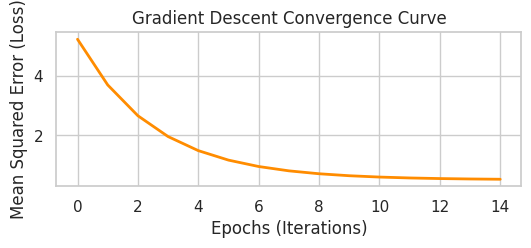

In [63]:
# Plot the loss history against the generated epochs
plt.figure(figsize=(6, 2)) 
plt.plot(gd_model.epochs_, gd_model.loss_history_, color='darkorange', linewidth=2)
plt.title('Gradient Descent Convergence Curve')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)

# save plot to file as png
plt.savefig('./Assets/gradient-descent-loss.png', bbox_inches='tight', dpi=300)
plt.show()


#### Actual Vs Predicted Plots
The following plots show the actual vs predicted values for the three models

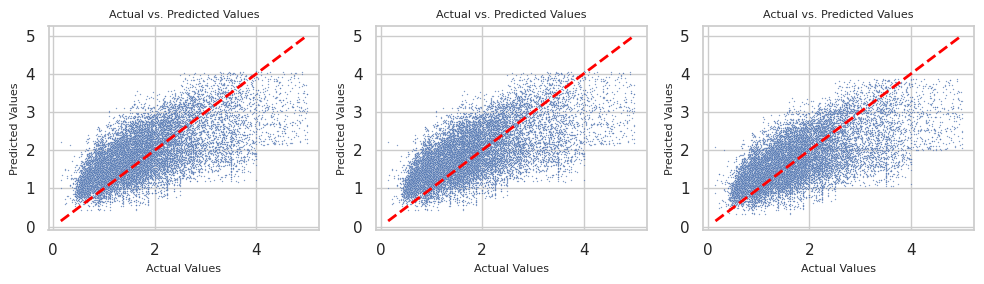

In [64]:
# Plots the actual vs predicted values for the three models in a single plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,3))

# my_linear_regression model
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test_housing, y=y_pred_housing, s=1, alpha=0.7, color="b")

start = min(min(y_test_housing), min(y_pred_housing))
end = max(max(y_test_housing), max(y_pred_housing))
plt.plot([start, end], [start, end], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = x)")

plt.title("Actual vs. Predicted Values", fontsize=8)
plt.xlabel("Actual Values", fontsize=8)
plt.ylabel("Predicted Values", fontsize=8)

# SkLearn model
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_test_housing, y=y_pred_housing_skln, s=1, alpha=0.7, color="b")

start = min(min(y_test_housing), min(y_pred_housing_skln))
end = max(max(y_test_housing), max(y_pred_housing_skln))
plt.plot([start, end], [start, end], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = x)")

plt.title("Actual vs. Predicted Values", fontsize=8)
plt.xlabel("Actual Values", fontsize=8)
plt.ylabel("Predicted Values", fontsize=8)

# Gradient Descent model
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test_housing, y=y_pred_housing_GD, s=1, alpha=0.7, color="b")   

start = min(min(y_test_housing), min(y_pred_housing_GD))
end = max(max(y_test_housing), max(y_pred_housing_GD))
plt.plot([start, end], [start, end], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = x)")

plt.title("Actual vs. Predicted Values", fontsize=8)
plt.xlabel("Actual Values", fontsize=8)
plt.ylabel("Predicted Values", fontsize=8)

plt.tight_layout()

# save plot to file as png
plt.savefig('./Assets/predictions.png', bbox_inches='tight', dpi=300)
plt.show()


#### Regression Lines Plots
The following plots shows the three models with the regression lines, coefficients and intercepts showing the relationship between the input feature and the target values. 

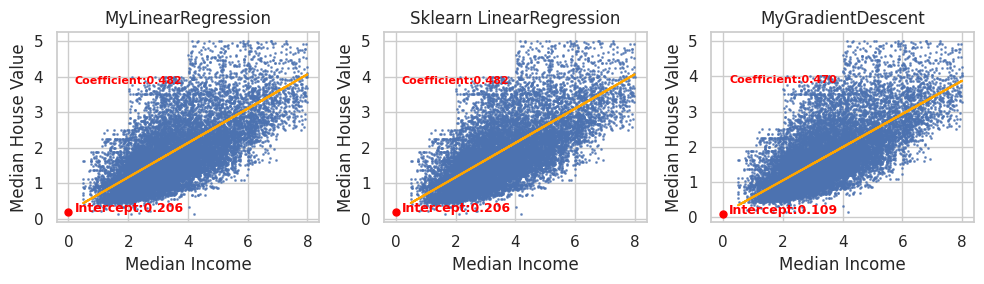

In [75]:
plt.figure(figsize=(10, 3)) 

# MyLinearRegression plot
plt.subplot(1, 3, 1)

plt.scatter(X_test_housing[:, 0], y_test_housing, s=1, alpha=0.7) 
plt.plot(X_test_housing[:, 0], y_pred_housing, c='orange')

plt.plot(0, custom_model.intercept_, marker='o', markersize=5, color="red")
plt.text(0.2, custom_model.intercept_, f"Intercept:{custom_model.intercept_:.3f}", fontsize=9, color="red", weight="bold")
plt.text(0.2, 3.8, f"Coefficient:{custom_model.coef_:.3f}", fontsize=8, color="red", weight="bold")

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("MyLinearRegression")

# Sklearn LinearRegression plot 
plt.subplot(1, 3, 2) 

plt.scatter(X_test_housing, y_test_housing, s=1, alpha=0.7)
plt.plot(X_test_housing, y_pred_housing_skln, c='orange')

plt.plot(0, sklearn_model.intercept_, marker='o', markersize=5, color="red")
plt.text(0.2, sklearn_model.intercept_, f"Intercept:{sklearn_model.intercept_:.3f}", fontsize=9, color="red", weight="bold")
plt.text(0.2, 3.8, f"Coefficient:{sklearn_model.coef_[0]:.3f}", fontsize=8, color="red", weight="bold")

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Sklearn LinearRegression")

# MyGradientDescent plot
plt.subplot(1, 3, 3)

plt.scatter(X_test_housing[:, 0], y_test_housing, s=1, alpha=0.7)
plt.plot(X_test_housing[:, 0], y_pred_housing_GD, c='orange')

plt.plot(0, gd_model.intercept_, marker='o', markersize=5, color="red")
plt.text(0.2, gd_model.intercept_, f"Intercept:{gd_model.intercept_:.3f}", fontsize=9, color="red", weight="bold")
plt.text(0.2, 3.8, f"Coefficient:{gd_model.coef_:.3f}", fontsize=8, color="red", weight="bold")

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("MyGradientDescent")

plt.tight_layout()

# save plot to file as png
plt.savefig('./Assets/regression-lines.png', bbox_inches='tight', dpi=300)
plt.show()

plt.show()

#### Residuals Comparison Plot
The plots below show the residuals in comparison with predicted values from each model. The residual is the difference between the predicted value and the the actual value. The residuals follow a non linear pattern and are not randomly distribuited. 

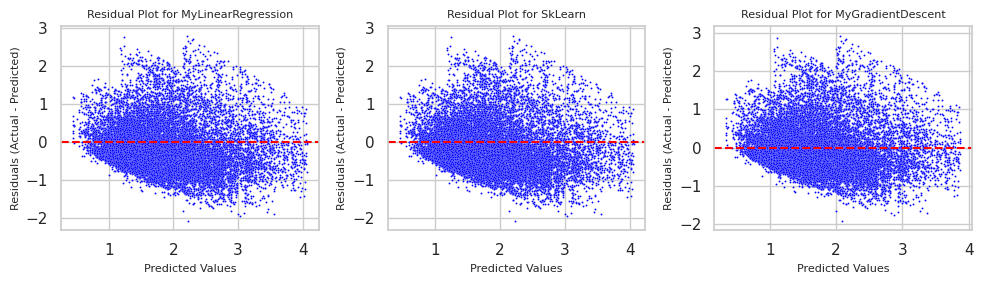

In [66]:
plt.figure(figsize=(10, 3))

# Calculate residuals for the MyLinearRegression model
custom_residuals = [true - pred for true, pred in zip(y_test_housing, y_pred_housing)]
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_housing, y=custom_residuals, color='blue', s=2)
plt.axhline(y=0, color='red', linestyle='--')  # Zero error baseline)

plt.title('Residual Plot for MyLinearRegression', fontsize=8)
plt.xlabel('Predicted Values', fontsize=8)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=8)

# Calculate residuals for the SkLearn model
sklearn_residuals = [true - pred for true, pred in zip(y_test_housing, y_pred_housing_skln)]
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_pred_housing_skln, y=sklearn_residuals, color='blue', s=2)
plt.axhline(y=0, color='red', linestyle='--')  # Zero error baseline)

plt.title('Residual Plot for SkLearn', fontsize=8)
plt.xlabel('Predicted Values', fontsize=8)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=8)

# Calculate residuals for the MyGradientDescent model
gd_residuals = [true - pred for true, pred in zip(y_test_housing, y_pred_housing_GD)]
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_pred_housing_GD, y=gd_residuals, color='blue', s=2)
plt.axhline(y=0, color='red', linestyle='--')  # Zero error baseline)

plt.title('Residual Plot for MyGradientDescent', fontsize=8)
plt.xlabel('Predicted Values', fontsize=8)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=8)

plt.tight_layout()

# save plot to file as png
plt.savefig('./Assets/residuals.png', bbox_inches='tight', dpi=300)
plt.show()


### Metrics Comparison
The following table compares the data outputs for each model. 

In [57]:
comp_table = pd.DataFrame({"Model": ["MyLinearRegression", "Sklearn LinearRegression", "MyGradientDescent"],
                           "Intercept": [custom_model.intercept_, sklearn_model.intercept_, gd_model.intercept_],
                           "Coefficient": [custom_model.coef_, sklearn_model.coef_[0], gd_model.coef_],
                           "Score": [my_simple_score, sklearn_score, my_grad_score],
                           "MAE": [my_simple_mae, sklearn_mae, my_grad_mae],
                           "RMSE": [my_simple_rmse, sklearn_rmse, my_grad_rmse],
                           })
comp_table

,Model,Intercept,Coefficient,Score,MAE,RMSE
0,MyLinearRegression,0.206095,0.482126,0.412818,0.544477,0.687978
1,Sklearn LinearRegression,0.206095,0.482126,0.412818,0.544477,0.687978
2,MyGradientDescent,0.109036,0.470477,0.425405,0.519747,0.680564


The custom implementation of simple linear regression was an important part of this project to understand how the algorithm affects predictions and accuracy. By comparing my custom model with the SkLearn version, I verified that my implementation was correct, as it showed exactly the same performance.  
However, the main goal of this project is to compare the methodology and performance of the sum of the least square residuals against gradient descent recursive learning.  
#### Methodology Differences
The underlying approach is different for each model:
- Simple Linear Regression: Uses the derivative of the Least Square Loss function to directly calculate the coefficient and intercept for the data set.
- Gradient Descent: Starts with random values to calculate the Mean Square Error (MSE). If the error is too big, the algorithm uses alpha and the derivative of the loss function to iteratively adjust the intercept and coefficient until the gradient error is closer to zero.
#### Performance Analysis
The table shows the performance of the models, where MyGradientDescent achieved the best score performance, the lowest Mean Absolute Error (MAE) rate, and the lowest variance rate.  Gradient descent can be more precise due to this iteration process to find the best fit. However, this algorithm is more sensitive to outliers, which can make the calculated values less precise than simple linear regression.  

Furthermore, a deeper evaluation of the residual plots generated during the evaluation phase revealed that a linear model is not ideal for this data. The residuals exhibited clear patterns rather than a random distribution, indicating that the underlying relationships in the dataset are non-linear and that both models suffered from low overall performance as a result.

#### Key Takeaways
When starting this comparison, I had the idea that these were two very different linear regression models. However, I soon noticed that both algorithms share the same goal.  Ultimately, gradient descent is an expansion of simple linear regression where the main purpose remains minimizing the cost or error from each gradient.


 	

## Conclusion
In conclusion, this project focus on understanding the differences of using simple costume linear regression and gradient descent regression.
The California Housing dataset was used to train and predict the regression line for both models.  
This report starts by defining the concepts and methodologies about linear regression and gradient descent. Then both algorithms where design and compared with sklearn linear regression algorithm. For the evaluation the score, MAE and RMSE where calculated and the coefficient and intercept where plotted for comparison.

In conclusion, this project focused on understanding the differences between using a custom simple linear regression model and a gradient descent regression model. The California Housing dataset was used to train both models and predict their respective regression lines. This report defined the core concepts and methodologies of linear regression and gradient descent, after which both algorithms were designed and compared against the SkLearn linear regression model. For the evaluation phase, the score, MAE, and RMSE were calculated, and the coefficient and intercept were plotted.  

Ultimately, while MyGradientDescent delivered the optimal metric scores, the low overall performance and patterned residual plots proved that a linear approach cannot adequately capture the complexities of this dataset.

### Proposed Future Improvements
To resolve these performance limitations and address the issues highlighted by the residual plots, the following steps are proposed for future work:
- Polynomial Regression: Implement polynomial features to let the regression models capture the non-linear curves visible in the data.
- Advanced Non-Linear Models: Transition to tree-based algorithms like Random Forests or Gradient Boosting, which inherently handle complex feature interactions without assuming linearity.
- Outlier Mitigation: Apply robust scaling or isolation forests to handle extreme housing values that heavily skewed the gradient descent updates.
- Feature Engineering: Combine or transform highly correlated geographical or economic variables to give the algorithms cleaner target patterns.

## References
PennState Eberly College of Science. “2.1 - What is Simple Linear Regression? | STAT 462.” STAT ONLINE, https://online.stat.psu.edu/stat462/node/91/. Accessed 31 December 2023.  

Scikit Learn. “sklearn.linear_model.LinearRegression — scikit-learn 1.3.2 documentation.” Scikit-learn, https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression. Accessed 31 December 2023. 

“Simple linear regression.” Wikipedia, https://en.wikipedia.org/wiki/Simple_linear_regression. Accessed 31 December 2023.  

SkLearn.datasets. “sklearn.datasets.fetch_california_housing — scikit-learn 1.3.2 documentation.” Scikit-learn, https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing. Accessed 4 January 2024.  

SkLearn.Feature_selection. “sklearn.feature_selection.SelectKBest — scikit-learn 1.3.2 documentation.” Scikit-learn, https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html. Accessed 4 January 2024.  

StatLib. “StatLib---Datasets Archive.” http:lib.stat.cmu.edu., http://lib.stat.cmu.edu/datasets/. Accessed 4 January 2024.  
